In [1]:
!pip install category_encoders


[notice] A new release of pip is available: 23.1.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Importer les bibliothèques nécessaires
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [3]:
# Charger les données
print("Chargement des données...")
X_train = pd.read_csv("train_input.csv")
y_train = pd.read_csv("train_output.csv")
X_test = pd.read_csv("test_input.csv")
print("Données chargées avec succès.")

Chargement des données...


C:\Users\anais\AppData\Local\Temp\ipykernel_14316\2527114055.py:3: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_train = pd.read_csv("train_input.csv")
C:\Users\anais\AppData\Local\Temp\ipykernel_14316\2527114055.py:5: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_test = pd.read_csv("test_input.csv")


Données chargées avec succès.


In [4]:
print("train shape: ", X_train.shape)
print("test shape: ", X_test.shape)

train shape:  (383610, 374)
test shape:  (95852, 374)


In [5]:
# Afficher un aperçu des données pour vérifier leur chargement
print("Aperçu de X_train :")
display(X_train.head())
print("Aperçu de y_train :")
display(y_train.head())
print("Aperçu de X_test :")
display(X_test.head())

Aperçu de X_train :


,ID,ACTIVIT2,VOCATION,TYPERS,ANCIENNETE,ADOSS,CARACT1,CARACT2,CARACT3,INDEM1,...,NBJRR100_MMAX_A,NBJRR100_MSOM_A,RR_VOR_MM_A,RR_VOR_MMAX_A,RRAB_VOR_MM_A,RRAB_VOR_MMAX_A,ANNEE_ASSURANCE,ESPINSEE,AN_EXERC,ZONE
0,1,ACT1,VOC6,1,0,N,N,NaN,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,ANNEE5,3
1,2,ACT1,VOC6,1,0,N,N,NaN,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,ANNEE5,3
2,3,ACT1,VOC6,1,2,N,R,NaN,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,0.402740,NaN,ANNEE5,3
3,4,ACT1,VOC6,2,0,N,N,NaN,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,0.246575,NaN,ANNEE5,3
4,5,ACT1,VOC6,2,1,N,N,NaN,NaN,N,...,01. <= 0,01. <= 0,03. <= 102,03. <= 232,04. >= 25,02. <= 57,0.838356,NaN,ANNEE5,3


Aperçu de y_train :


,ID,FREQ,CM,ANNEE_ASSURANCE,CHARGE
0,1,0.0,0.0,1.000000,0.0
1,2,0.0,0.0,1.000000,0.0
2,3,0.0,0.0,0.402740,0.0
3,4,0.0,0.0,0.246575,0.0
4,5,0.0,0.0,0.838356,0.0


Aperçu de X_test :


,ID,ACTIVIT2,VOCATION,TYPERS,ANCIENNETE,ADOSS,CARACT1,CARACT2,CARACT3,INDEM1,...,NBJRR100_MMAX_A,NBJRR100_MSOM_A,RR_VOR_MM_A,RR_VOR_MMAX_A,RRAB_VOR_MM_A,RRAB_VOR_MMAX_A,ANNEE_ASSURANCE,ESPINSEE,AN_EXERC,ZONE
0,383611,ACT1,VOC6,2,4,N,R,NaN,NaN,N,...,01. <= 0,01. <= 0,03. <= 102,03. <= 232,03. <= 25,02. <= 57,0.813699,NaN,ANNEE5,3
1,383612,ACT1,VOC6,2,6,N,R,NaN,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,ANNEE5,3
2,383613,ACT1,VOC7,2,2,N,N,NaN,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,0.586301,NaN,ANNEE5,3
3,383614,ACT2,VOC1,2,2,N,N,NaN,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,ANNEE5,3
4,383615,ACT2,VOC1,2,3,N,R,NaN,NaN,N,...,01. <= 0,01. <= 0,02. <= 79,02. <= 176,03. <= 25,02. <= 57,0.753425,NaN,ANNEE5,3


In [6]:
print("train input dataset description:")
display(X_train.describe())
print("train output dataset description:")
display(y_train.describe())


train input dataset description:


,ID,TYPERS,ANCIENNETE,CARACT2,DUREE_REQANEUF,CARACT5,TYPBAT2,DEROG15,CA1,CA2,...,RISK5,RISK7,EQUIPEMENT1,EQUIPEMENT3,EQUIPEMENT4,EQUIPEMENT6,EQUIPEMENT7,ZONE_VENT,ANNEE_ASSURANCE,ZONE
count,383610.000000,383610.000000,383610.000000,15326.000000,357037.000000,383610.000000,383610.000000,383610.000000,383610.000000,383610.000000,...,357037.000000,357037.000000,383610.000000,383610.000000,383610.000000,383610.000000,383610.000000,365028.00000,383610.000000,383610.000000
mean,191805.500000,1.665368,5.175517,1.019053,2.200483,0.076515,1.061711,99.997263,1047.396444,4.105732,...,448.326103,92.964861,0.074740,0.029454,0.899468,5.905349,6.851302,1.92568,0.701557,49.046876
std,110738.812719,0.471862,3.823097,0.136714,1.300343,0.420928,0.831133,0.286544,4777.346410,329.381340,...,494.892793,8.902888,0.262972,0.566816,0.300708,4.290611,4.329113,0.62817,0.352375,27.919867
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,...,0.000000,75.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.002732,1.000000
25%,95903.250000,1.000000,2.000000,1.000000,2.000000,0.000000,0.000000,100.000000,0.000000,0.000000,...,4.000000,90.000000,0.000000,0.000000,1.000000,3.000000,4.000000,2.00000,0.389041,25.000000
50%,191805.500000,2.000000,5.000000,1.000000,2.000000,0.000000,1.000000,100.000000,0.000000,0.000000,...,5.000000,100.000000,0.000000,0.000000,1.000000,5.000000,6.000000,2.00000,0.882192,49.000000
75%,287707.750000,2.000000,9.000000,1.000000,2.000000,0.000000,2.000000,100.000000,0.000000,0.000000,...,1000.000000,100.000000,0.000000,0.000000,1.000000,8.000000,9.000000,2.00000,1.000000,73.000000
max,383610.000000,2.000000,11.000000,2.000000,10.000000,20.000000,2.000000,100.000000,30000.000000,30000.000000,...,1000.000000,500.000000,1.000000,87.000000,1.000000,21.000000,21.000000,3.00000,2.000000,95.000000


train output dataset description:


,ID,FREQ,CM,ANNEE_ASSURANCE,CHARGE
count,383610.000000,383610.000000,383610.000000,383610.000000,383610.000000
mean,191805.500000,0.012452,182.521632,0.701557,186.087058
std,110738.812719,0.357127,6699.967429,0.352375,6800.490328
min,1.000000,0.000000,-5751.000000,0.002732,-5751.000000
25%,95903.250000,0.000000,0.000000,0.389041,0.000000
50%,191805.500000,0.000000,0.000000,0.882192,0.000000
75%,287707.750000,0.000000,0.000000,1.000000,0.000000
max,383610.000000,182.499998,500000.000000,2.000000,552000.000000


In [7]:
print("train input datasetinfo:")
display(X_train.info())
print("train output dataset info:")
display(y_train.info())

train input datasetinfo:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383610 entries, 0 to 383609
Columns: 374 entries, ID to ZONE
dtypes: float64(36), int64(58), object(280)
memory usage: 1.1+ GB


None

train output dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383610 entries, 0 to 383609
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ID               383610 non-null  int64  
 1   FREQ             383610 non-null  float64
 2   CM               383610 non-null  float64
 3   ANNEE_ASSURANCE  383610 non-null  float64
 4   CHARGE           383610 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 14.6 MB


None

In [8]:
#  Check if there are any duplicated observations in the datasets, if true delete the duplicated observationsand print the new shape.
num_duplicates_train = X_train.duplicated().sum()
print(f"Number of train duplicated rows: {num_duplicates_train}")
num_duplicates_test = X_test.duplicated().sum()
print(f"Number of test duplicated rows: {num_duplicates_test}")

X_train = X_train.drop_duplicates()
print(" X_train New shape: {}".format(X_train.shape))
X_test = X_test.drop_duplicates()
print("X_test New shape: {}".format(X_test.shape))

Number of train duplicated rows: 0
Number of test duplicated rows: 0
 X_train New shape: (383610, 374)
X_test New shape: (95852, 374)


In [9]:
#check missing values 
print("Missing values of train data:")
missing_train_values = X_train.isna().sum().sort_values(ascending=False)
n_missing_train_values = missing_train_values[missing_train_values>0]
p_missing_train_values = (n_missing_train_values/ X_train.shape[0])*100
missing_train_data = pd.concat([n_missing_train_values,p_missing_train_values], axis=1, keys=['Count', 'Percentage'])

print(missing_train_data)
print(" ")

print("Missing values of test data:")
missing_test_values = X_test.isna().sum().sort_values(ascending=False)
n_missing_test_values = missing_test_values[missing_test_values>0]
p_missing_test_values = (n_missing_test_values/ X_test.shape[0])*100
missing_test_data = pd.concat([n_missing_test_values,p_missing_test_values], axis=1, keys=['Count', 'Percentage'])
print(missing_test_data)


Missing values of train data:
            Count  Percentage
DEROG14    383602   99.997915
DEROG13    382317   99.662939
DEROG16    380358   99.152264
CARACT2    368284   96.004797
CARACT3    368284   96.004797
...           ...         ...
KAPITAL15     624    0.162665
KAPITAL20     268    0.069863
KAPITAL18      48    0.012513
KAPITAL31       3    0.000782
KAPITAL33       3    0.000782

[278 rows x 2 columns]
 
Missing values of test data:
           Count  Percentage
DEROG14    95850   99.997913
DEROG13    95518   99.651546
DEROG16    94982   99.092351
CARACT2    91998   95.979218
CARACT3    91998   95.979218
...          ...         ...
KAPITAL17    249    0.259775
KAPITAL24    183    0.190919
KAPITAL15    139    0.145015
KAPITAL20     67    0.069899
KAPITAL18      7    0.007303

[276 rows x 2 columns]


In [10]:
#Drop the columns that have more than 40% missing values and print the new shape of the dataset.

drop_train_columns= p_missing_train_values [p_missing_train_values  > 40].index
X_train= X_train.drop(drop_train_columns, axis=1)
print("New dataset : {}".format(X_train.shape))
X_train.head()


New dataset : (383610, 190)


,ID,ACTIVIT2,VOCATION,TYPERS,ANCIENNETE,ADOSS,CARACT1,INDEM1,DUREE_REQANEUF,CARACT4,...,ZONE_VENT,NB_CASERNES,FFM_VOR_COM_MM_A_Y,FFM_VOR_COM_MMAX_A_Y,FXI3SAB_VOR_COM_MM_A_Y,FXI3SAB_VOR_COM_MMAX_A_Y,ANNEE_ASSURANCE,ESPINSEE,AN_EXERC,ZONE
0,1,ACT1,VOC6,1,0,N,N,N,NaN,absence de surface,...,2.0,02. <= 3,02. <= 3,02. <= 4,01. <= 4,01. <= 5,1.000000,NaN,ANNEE5,3
1,2,ACT1,VOC6,1,0,N,N,N,NaN,absence de surface,...,2.0,01. <= 1,03. <= 4,02. <= 4,03. <= 23,03. <= 30,1.000000,NaN,ANNEE5,3
2,3,ACT1,VOC6,1,2,N,R,N,NaN,absence de surface,...,2.0,01. <= 1,02. <= 3,02. <= 4,03. <= 23,03. <= 30,0.402740,NaN,ANNEE5,3
3,4,ACT1,VOC6,2,0,N,N,N,NaN,absence de surface,...,2.0,01. <= 1,02. <= 3,02. <= 4,01. <= 4,01. <= 5,0.246575,NaN,ANNEE5,3
4,5,ACT1,VOC6,2,1,N,N,N,NaN,absence de surface,...,1.0,01. <= 1,01. <= 1,01. <= 2,01. <= 4,01. <= 5,0.838356,NaN,ANNEE5,3


In [11]:
#Drop the columns that have more than 40% missing values and print the new shape of the dataset.

drop_test_columns= p_missing_test_values [p_missing_test_values  > 40].index
X_test= X_test.drop(drop_test_columns, axis=1)
print("New test dataset : {}".format(X_test.shape))
X_test.head()

New test dataset : (95852, 190)


,ID,ACTIVIT2,VOCATION,TYPERS,ANCIENNETE,ADOSS,CARACT1,INDEM1,DUREE_REQANEUF,CARACT4,...,ZONE_VENT,NB_CASERNES,FFM_VOR_COM_MM_A_Y,FFM_VOR_COM_MMAX_A_Y,FXI3SAB_VOR_COM_MM_A_Y,FXI3SAB_VOR_COM_MMAX_A_Y,ANNEE_ASSURANCE,ESPINSEE,AN_EXERC,ZONE
0,383611,ACT1,VOC6,2,4,N,R,N,NaN,absence de surface,...,2.0,01. <= 1,02. <= 3,02. <= 4,01. <= 4,01. <= 5,0.813699,NaN,ANNEE5,3
1,383612,ACT1,VOC6,2,6,N,R,N,NaN,absence de surface,...,1.0,01. <= 1,02. <= 3,02. <= 4,01. <= 4,01. <= 5,1.000000,NaN,ANNEE5,3
2,383613,ACT1,VOC7,2,2,N,N,N,NaN,absence de surface,...,2.0,02. <= 3,02. <= 3,02. <= 4,03. <= 23,03. <= 30,0.586301,NaN,ANNEE5,3
3,383614,ACT2,VOC1,2,2,N,N,N,NaN,absence de surface,...,2.0,01. <= 1,02. <= 3,02. <= 4,03. <= 23,03. <= 30,1.000000,NaN,ANNEE5,3
4,383615,ACT2,VOC1,2,3,N,R,N,NaN,absence de surface,...,2.0,02. <= 3,02. <= 3,02. <= 4,03. <= 23,03. <= 30,0.753425,NaN,ANNEE5,3


In [12]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383610 entries, 0 to 383609
Columns: 190 entries, ID to ZONE
dtypes: float64(35), int64(58), object(97)
memory usage: 556.1+ MB


In [13]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95852 entries, 0 to 95851
Columns: 190 entries, ID to ZONE
dtypes: float64(33), int64(60), object(97)
memory usage: 138.9+ MB


In [14]:
# Traitement des valeurs manquantes dans les colonnes numériques
print("Traitement des valeurs manquantes dans les colonnes numériques....")

numeric_columns = X_train.select_dtypes(include=['number']).columns

# Remplir les NaN avec 0 pour les colonnes numériques
X_train[numeric_columns] = X_train[numeric_columns].fillna(0)

# Identifier les colonnes non numériques
fill_cols = [item for item in X_train.columns if item not in numeric_columns]

# Remplir les NaN des colonnes non numériques avec une valeur par défaut (-999)
X_train[fill_cols] = X_train[fill_cols].fillna(-999)

print("Traitement des valeurs manquantes terminé.")

Traitement des valeurs manquantes dans les colonnes numériques....
Traitement des valeurs manquantes terminé.


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import pandas as pd

# 1. Identifier les colonnes catégorielles
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# ✅ Conversion explicite en string pour éviter l'erreur OrdinalEncoder
X_train[categorical_cols] = X_train[categorical_cols].astype(str)
X_test[categorical_cols] = X_test[categorical_cols].astype(str)

# 2. Pipeline pour les colonnes catégorielles
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# 3. ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'
)

# 4. Transformation
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# 5. Colonnes encodées
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]
all_col_names = categorical_cols + numeric_cols

# 6. Conversion en DataFrame
X_train_encoded = pd.DataFrame(X_train_transformed, columns=all_col_names)
X_test_encoded = pd.DataFrame(X_test_transformed, columns=all_col_names)
X_train_encoded.head()
X_train_encoded.info()
X_test_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383610 entries, 0 to 383609
Columns: 190 entries, ACTIVIT2 to ZONE
dtypes: float64(190)
memory usage: 556.1 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95852 entries, 0 to 95851
Columns: 190 entries, ACTIVIT2 to ZONE
dtypes: float64(190)
memory usage: 138.9 MB


In [36]:
import numpy as np

# Corrélation entre les features et la cible
correlations = X_train_encoded.corrwith(y_train["CHARGE"])

# Affichage trié des corrélations
print(correlations.sort_values(ascending=False))

# Seuil pour ne conserver que les features corrélées
threshold = 0.01
strong_corr_features = correlations[correlations.abs() > threshold].index.tolist()

# Réduction du dataset à ces features
X_train_reduced = X_train_encoded[strong_corr_features]
X_test_reduced = X_test_encoded[strong_corr_features]
X_train_reduced.info()
X_test_reduced.info()

SURFACE2     0.032238
SURFACE1     0.032237
TAILLE1      0.032020
TAILLE2      0.028686
KAPITAL32    0.027153
               ...   
RISK3       -0.008172
RISK4       -0.008209
RISK1       -0.008210
RISK5       -0.008212
TYPERS      -0.016160
Length: 190, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383610 entries, 0 to 383609
Data columns (total 35 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   TAILLE1      383610 non-null  float64
 1   TAILLE2      383610 non-null  float64
 2   KAPITAL40    383610 non-null  float64
 3   KAPITAL41    383610 non-null  float64
 4   KAPITAL43    383610 non-null  float64
 5   SURFACE4     383610 non-null  float64
 6   SURFACE6     383610 non-null  float64
 7   TYPERS       383610 non-null  float64
 8   KAPITAL6     383610 non-null  float64
 9   KAPITAL7     383610 non-null  float64
 10  KAPITAL9     383610 non-null  float64
 11  KAPITAL10    383610 non-null  float64
 12  KAPITAL11   

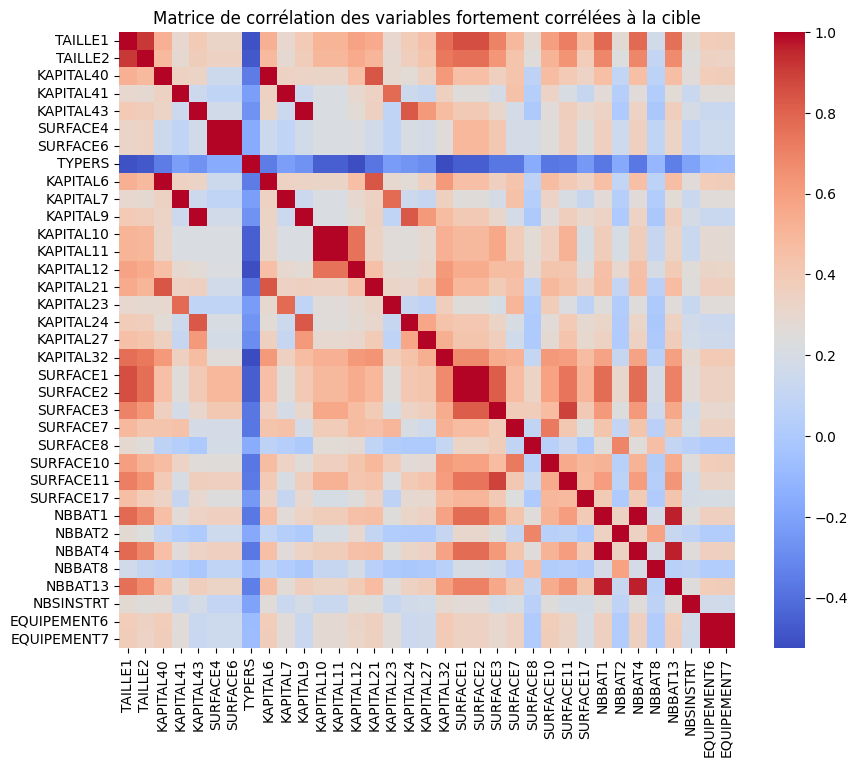

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Affichage de la matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(X_train_reduced.corr(), cmap='coolwarm', fmt=".2f", square=True)
plt.title("Matrice de corrélation des variables fortement corrélées à la cible")
plt.show()

In [18]:
from sklearn.ensemble import RandomForestRegressor
# Entraîner les modèles
print("Entraînement des modèles")



# Modèle pour prédire 'FREQ'
rf_freq = RandomForestRegressor(random_state=42)
rf_freq.fit(X_train_, y_train['FREQ'])
print("Modèle pour 'FREQ' entraîné avec succès.")


Entraînement des modèles
Modèle pour 'FREQ' entraîné avec succès.


In [19]:
# Prédire 'FREQ' sur l'ensemble d'entraînement
y_train_pred_freq = rf_freq.predict(X_train_reduced)

In [20]:
# Modèle pour prédire 'CM'
gb_cm = GradientBoostingRegressor(random_state=42)
gb_cm.fit(X_train_reduced, y_train['CM'])
print("Modèle pour 'CM' entraîné avec succès.")

Modèle pour 'CM' entraîné avec succès.


In [22]:
# Prédire 'CM' sur l'ensemble d'entraînement
y_train_pred_cm = gb_cm.predict(X_train_reduced)

In [24]:
# Calculer la prédiction combinée pour 'CHARGE'
y_train_pred = y_train_pred_freq * y_train_pred_cm * y_train['ANNEE_ASSURANCE']

In [25]:
# Calculer le RMSE sur l'ensemble d'entraînement
rmse = np.sqrt(mean_squared_error(y_train['CHARGE'], y_train_pred))
print(f"RMSE sur l'ensemble d'entraînement : {rmse:.2f}")

RMSE sur l'ensemble d'entraînement : 6758.97


In [40]:
# Prédictions sur l'ensemble de test
print("Prédictions sur l'ensemble de test...")

# Prédire 'FREQ' et 'CM' sur les données de test
y_pred_freq = rf_freq.predict(X_test_reduced)
y_pred_cm = gb_cm.predict(X_test_reduced)
print("fin Prédictions sur l'ensemble de test")

Prédictions sur l'ensemble de test...
fin Prédictions sur l'ensemble de test


In [41]:
# Combiner les prédictions
y_pred = pd.concat([
    X_test[['ID', 'ANNEE_ASSURANCE']].reset_index(drop=True),
    pd.DataFrame(y_pred_freq, columns=['FREQ']),
    pd.DataFrame(y_pred_cm, columns=['CM'])
], axis=1)

In [42]:
#Calculer la colonne 'CHARGE' en multipliant 'FREQ', 'CM' et 'ANNEE_ASSURANCE'
y_pred['CHARGE'] = y_pred['CM'] * y_pred['FREQ'] * y_pred['ANNEE_ASSURANCE']

print("Prédictions terminées.")

Prédictions terminées.


In [43]:
# Exporter les prédictions dans un fichier CSV
print("Exportation des résultats...")
y_pred.to_csv('submission_anais_ouali.csv', index=False)
print("Fichier de soumission créé : 'submission_anais_ouali.csv'")

Exportation des résultats...
Fichier de soumission créé : 'submission_anais_ouali.csv'


Objective: Improve the predictions!

In [89]:
#Méthode evaluate 03 

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

# Fonction d'évaluation
def evaluation(models, X_train, y_train, metric):
    for model_key in models:
        model_info = models[model_key]
        scores = cross_val_score(model_info['model'], X_train, y_train, cv=3, scoring=metric)
        model_info['score'] = scores
        print(f"{model_info['name']} : {scores.mean():.4f} (+/- {scores.std()**2:.4f})")



In [100]:
models = {'gbc': {'model': GradientBoostingRegressor(), 'name': 'GradientBoostingRegressor'},
          'rf': {'model': RandomForestRegressor( n_jobs=-1), 'name':'RandomForestRegressor'},
          'tree': {'model': DecisionTreeRegressor(), 'name':'DecisionTreeRegressor'},
          'svr': {'model': SVR(), 'name': 'SVR'},
          'knn': {'model': KNeighborsRegressor(), 'name': 'KNeighborsRegressor'},
          'lr': {'model': LinearRegression(), 'name': 'LinearRegression'},
          'ridge': {'model': Ridge(), 'name': 'Ridge'},
          'lasso': {'model': Lasso(), 'name': 'Lasso'}
         }


print (" Résultat évaluation  de FREQ : ")
evaluation(models, X_train_reduced, y_train['FREQ'], rmse_scorer)

print (" Résultat évaluation de CM : ")
evaluation(models, X_train_reduced, y_train['CM'], rmse_scorer)



 Résultat évaluation  n3  de FREQ : 
GradientBoostingRegressor : -0.3423 (+/- 0.0223)
RandomForestRegressor : -0.4687 (+/- 0.0354)
DecisionTreeRegressor : -0.7035 (+/- 0.1310)
SVR : -0.3319 (+/- 0.0250)
KNeighborsRegressor : -0.3445 (+/- 0.0206)
LinearRegression : -0.3172 (+/- 0.0273)


c:\users\anais\appdata\local\programs\python\python38\lib\site-packages\sklearn\linear_model\_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=6.43655e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\users\anais\appdata\local\programs\python\python38\lib\site-packages\sklearn\linear_model\_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=8.4935e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\users\anais\appdata\local\programs\python\python38\lib\site-packages\sklearn\linear_model\_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=4.98983e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Ridge : -0.3167 (+/- 0.0272)
Lasso : -0.3167 (+/- 0.0272)
 Résultat évaluation  n3  de CM : 
GradientBoostingRegressor : -6752.7474 (+/- 95218.2914)
RandomForestRegressor : -7337.2178 (+/- 76692.3728)
DecisionTreeRegressor : -11221.6616 (+/- 1042856.0476)
SVR : -6696.8340 (+/- 75138.2981)
KNeighborsRegressor : -7297.3736 (+/- 149174.0734)
LinearRegression : -6694.8328 (+/- 76151.1474)


c:\users\anais\appdata\local\programs\python\python38\lib\site-packages\sklearn\linear_model\_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=6.43655e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\users\anais\appdata\local\programs\python\python38\lib\site-packages\sklearn\linear_model\_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=8.4935e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\users\anais\appdata\local\programs\python\python38\lib\site-packages\sklearn\linear_model\_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=4.98983e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Ridge : -6691.2426 (+/- 75170.4211)


c:\users\anais\appdata\local\programs\python\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.668e+12, tolerance: 1.213e+09
  model = cd_fast.enet_coordinate_descent(
c:\users\anais\appdata\local\programs\python\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.200e+12, tolerance: 1.126e+09
  model = cd_fast.enet_coordinate_descent(


Lasso : -6691.2237 (+/- 75131.4116)


c:\users\anais\appdata\local\programs\python\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.378e+12, tolerance: 1.106e+09
  model = cd_fast.enet_coordinate_descent(


In [104]:
# Meilleur Modèle pour prédire 'FREQ'
print (" Prédiction de 'FREQ' avec le meilleur modèle 'Lasso' :")
freq_lasso = Lasso(random_state=42)
freq_lasso.fit(X_train_reduced, y_train['FREQ'])
print("Modèle Lasso pour 'FREQ' entraîné avec succès.")

 Prédiction de 'FREQ' avec le meilleur modèle 'Lasso' :
Modèle Lasso pour 'FREQ' entraîné avec succès.


In [105]:
# Lasso : Prédire 'FREQ' sur l'ensemble d'entraînement 
y_train_pred_freq_lasso = freq_lasso.predict(X_train_reduced)
print("Modèle Lasso : Prédiction de 'FREQ' sur l'ensemble d'entraînement  avec succès.")

Modèle Lasso : Prédiction de 'FREQ' sur l'ensemble d'entraînement  avec succès.


In [106]:
# Prédire 'CM' avec Ridge
print (" Prédiction de 'cm' avec  modèle 'Ridge' :")
cm_ridge = Ridge(random_state=42)
cm_ridge.fit(X_train_reduced, y_train['CM'])
print("Modèle Ridge pour 'CM' entraîné avec succès.")

 Prédiction de 'cm' avec  modèle 'Ridge' :
Modèle Ridge pour 'CM' entraîné avec succès.


c:\users\anais\appdata\local\programs\python\python38\lib\site-packages\sklearn\linear_model\_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=3.97518e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [107]:
# Prédire 'CM' sur l'ensemble d'entraînement
y_train_pred_cm_ridge = cm_ridge.predict(X_train_reduced)

In [110]:
# Calculer la prédiction combinée pour 'CHARGE'
y_train_pred_lr = y_train_pred_freq_lasso * y_train_pred_cm_ridge * y_train['ANNEE_ASSURANCE']

In [112]:
# Calculer le RMSE sur l'ensemble d'entraînement
rmse_2 = np.sqrt(mean_squared_error(y_train['CHARGE'], y_train_pred_lr))
print(f"RMSE sur l'ensemble d'entraînement : {rmse_2:.2f}")

RMSE sur l'ensemble d'entraînement : 6802.69
